# Домашнее задание: Multi-Branch MLP для Wine Quality

**Цель**: Реализовать multi-branch модель и добиться F1 score ≥ 40%

**Задачи**:
1. Реализовать три типа блоков: Bottleneck, Inverted Bottleneck, Regular
2. Создать Multi-Branch архитектуру
3. Использовать weighted loss для борьбы с дисбалансом классов
4. Подобрать оптимальные гиперпараметры (глубина, ширина, lr, оптимизатор)

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import sys
#sys.path.append('../../lesson3/seminar')
from wine_quality_data import WineQualityDataModule
from lightning_module import BaseLightningModule
from utils import set_seed
from pytorch_lightning import Trainer

sns.set_style('whitegrid')
set_seed(42)

## 1. Загрузка и анализ данных

Загрузим Wine Quality датасет и проанализируем распределение классов.

In [2]:
# Загружаем данные
dm = WineQualityDataModule(batch_size=128)
dm.setup()

print(f'Train samples: {len(dm.train_dataset)}')
print(f'Val samples: {len(dm.val_dataset)}')
print(f'Input dim: {dm.input_dim}')
print(f'Num classes: {dm.n_classes}')

Train samples: 1279
Val samples: 320
Input dim: 11
Num classes: 6


### 1.1. Анализ дисбаланса классов

Проанализируйте распределение классов и вычислите веса для weighted loss.

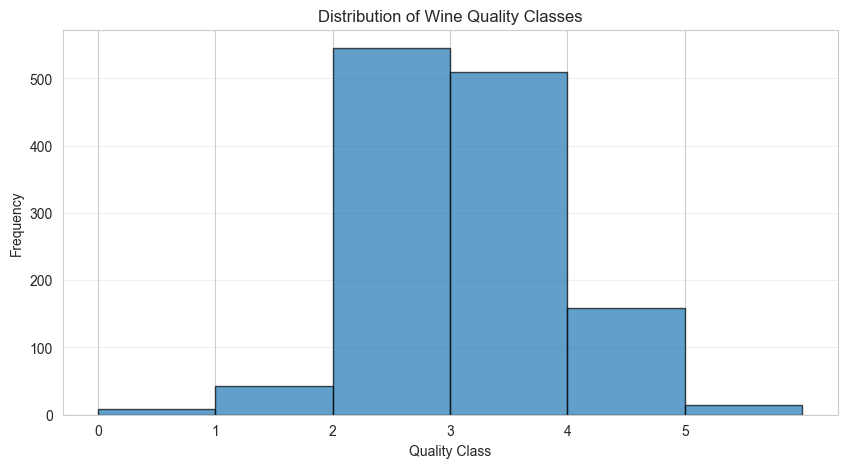

Class weights: [26.645834    5.075397    0.3911315   0.41797385  1.3406708  14.211111  ]


In [3]:
# TODO: Получите метки классов из train_dataset
train_labels = [dm.train_dataset[i][1].item() for i in range(len(dm.train_dataset))]


# TODO: Постройте гистограмму распределения классов
plt.figure(figsize=(10, 5))
plt.hist(train_labels, bins=range(dm.n_classes + 1), edgecolor='black', alpha=0.7)
plt.title('Distribution of Wine Quality Classes')
plt.xlabel('Quality Class')
plt.ylabel('Frequency')
plt.xticks(range(dm.n_classes))
plt.grid(axis='y', alpha=0.3)
plt.show()

# TODO: Вычислите веса классов
classes = np.arange(dm.n_classes)
class_weights = compute_class_weight('balanced', classes=classes, y=train_labels)
class_weights = torch.FloatTensor(class_weights).to('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Class weights: {class_weights.cpu().numpy()}')

## 2. Реализация блоков

Реализуйте три типа блоков:
- **Bottleneck**: dim → dim//4 → dim (сужение)
- **Inverted Bottleneck**: dim → dim*4 → dim (расширение)
- **Regular**: dim → hidden_dim → dim (обычный)

In [4]:
from abc import ABC, abstractmethod

class BaseMLPBlock(nn.Module, ABC):
    """Базовый класс для MLP блока"""
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__()
        self.dim = dim
        self.activation = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'swish': nn.SiLU()}.get(activation, nn.GELU())
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None
    
    @abstractmethod
    def forward(self, x):
        pass

class BottleneckBlock(BaseMLPBlock):
    """
    Bottleneck блок: dim → dim//4 → dim
    
    Сужает размерность в 4 раза, затем восстанавливает.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Bottleneck dimension (сужение в 4 раза)
        self.bottleneck_dim = max(dim // 4, 1)
        
        # Линейные слои: dim → bottleneck_dim → dim
        self.fc1 = nn.Linear(self.dim, self.bottleneck_dim)
        self.fc2 = nn.Linear(self.bottleneck_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

class InvertedBottleneckBlock(BaseMLPBlock):
    """
    Inverted Bottleneck блок: dim → dim*4 → dim
    
    Расширяет размерность в 4 раза, затем сжимает обратно.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, expansion_factor=4, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Expanded dimension (расширение в 4 раза)
        self.expanded_dim = dim * expansion_factor
        
        # Линейные слои: dim → expanded_dim → dim
        self.fc1 = nn.Linear(self.dim, self.expanded_dim)
        self.fc2 = nn.Linear(self.expanded_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Inverted bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

class RegularBlock(BaseMLPBlock):
    """
    Regular блок: dim → hidden_dim → dim
    
    Обычный двухслойный MLP с residual connection.
    hidden_dim по умолчанию равен dim * 2.
    """
    def __init__(self, dim, hidden_dim=None, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Hidden dimension (по умолчанию в 2 раза больше)
        self.hidden_dim = hidden_dim if hidden_dim else dim * 2
        
        # Линейные слои: dim → hidden_dim → dim
        self.fc1 = nn.Linear(self.dim, self.hidden_dim)
        self.fc2 = nn.Linear(self.hidden_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Regular pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

# Тестируем блоки
print('✓ Блоки успешно определены!')
print()

# Проверим размерности
test_x = torch.randn(4, 64)
print('Тестирование блоков с размерностью 64:')
print(f'  Input shape: {test_x.shape}')

bottleneck = BottleneckBlock(64)
print(f'  BottleneckBlock output: {bottleneck(test_x).shape}')

inverted = InvertedBottleneckBlock(64)
print(f'  InvertedBottleneckBlock output: {inverted(test_x).shape}')

regular = RegularBlock(64)
print(f'  RegularBlock output: {regular(test_x).shape}')

# Подсчитаем параметры
print()
print('Количество параметров:')
print(f'  BottleneckBlock: {sum(p.numel() for p in bottleneck.parameters()):,}')
print(f'  InvertedBottleneckBlock: {sum(p.numel() for p in inverted.parameters()):,}')
print(f'  RegularBlock: {sum(p.numel() for p in regular.parameters()):,}')

✓ Блоки успешно определены!

Тестирование блоков с размерностью 64:
  Input shape: torch.Size([4, 64])
  BottleneckBlock output: torch.Size([4, 64])
  InvertedBottleneckBlock output: torch.Size([4, 64])
  RegularBlock output: torch.Size([4, 64])

Количество параметров:
  BottleneckBlock: 2,128
  InvertedBottleneckBlock: 33,088
  RegularBlock: 16,576


## 3. Multi-Branch модель

Реализуйте модель с тремя параллельными ветками.

**Архитектура**:
```
         Input
           |
      projection
           |
      ┌────┼────┐
      │    │    │
  Bottleneck  Inverted  Regular
   Branch      Branch    Branch
      │    │    │
      └────┼────┘
           |
      Concatenate/Sum
           |
      projection
           |
        Output
```

In [ ]:
class MultiBranchMLP(nn.Module):
    """
    Multi-Branch MLP с тремя параллельными ветками.

    Args:
        input_dim: размерность входа
        hidden_dim: размерность скрытых слоев
        output_dim: размерность выхода (число классов)
        num_blocks: количество блоков в каждой ветке
        dropout: вероятность dropout
        combine_mode: способ объединения веток ('concat' или 'sum')
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_blocks=4,
        dropout=0.1,
        combine_mode='concat'
    ):
        super().__init__()
        self.output_dim = output_dim
        self.combine_mode = combine_mode

        # Входная проекция
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.bottleneck_branch = nn.Sequential(*[
            BottleneckBlock(hidden_dim, activation='gelu', dropout=dropout)
            for _ in range(num_blocks)
        ])
        self.inverted_branch = nn.Sequential(*[
            InvertedBottleneckBlock(hidden_dim, activation='gelu', dropout=dropout)
            for _ in range(num_blocks)
        ])
        self.regular_branch = nn.Sequential(*[
            RegularBlock(hidden_dim, activation='gelu', dropout=dropout)
            for _ in range(num_blocks)
        ])

        if combine_mode == 'concat':
            final_input_dim = hidden_dim * 3
        elif combine_mode == 'sum':
            final_input_dim = hidden_dim
        else:
            raise ValueError("combine_mode must be 'concat' or 'sum'")

        self.output_proj = nn.Linear(final_input_dim, output_dim)

    def forward(self, x):
        x = self.input_proj(x)

        out1 = self.bottleneck_branch(x)
        out2 = self.inverted_branch(x)
        out3 = self.regular_branch(x)

        if self.combine_mode == 'concat':
            out = torch.cat([out1, out2, out3], dim=-1)
        elif self.combine_mode == 'sum':
            out = out1 + out2 + out3

        out = self.output_proj(out)
        return out


print('Multi-Branch модель определена!')

Multi-Branch модель определена!


## 4. Код обучение

In [ ]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping
import torch
import torch.nn as nn

def train_model(
    model,
    dm,
    class_weights=None,
    max_epochs=50,
    lr=1e-3,
    optimizer_type='adam'
):


    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device.upper()}")


    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    else:
        loss_fn = nn.CrossEntropyLoss()


    model.to(device)


    lightning_model = BaseLightningModule(
        model=model,
        loss_fn=loss_fn,
        optimizer_type=optimizer_type,
        learning_rate=lr,
        task_type='multiclass'
    )


    early_stop = EarlyStopping(
        monitor='val_f1_macro',
        patience=5,
        mode='max',
        verbose=True
    )

    trainer = Trainer(
        max_epochs=max_epochs,
        devices=1,
        accelerator=device,
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        enable_model_summary=False,
        callbacks=[early_stop],
        deterministic=True,
    )

    trainer.fit(lightning_model, dm)

    metrics = trainer.callback_metrics
    val_acc = metrics.get('val_accuracy', 0).item()
    val_f1 = metrics.get('val_f1_macro', 0).item()

    return {'val_acc': val_acc, 'val_f1': val_f1}


## 5. Итоговая модель

Обучите модель с лучшими гиперпараметрами.

In [ ]:
from itertools import product


hidden_dims = [64, 128, 256]
num_blocks_list = [2, 4, 6, 8]
lrs = [1e-3, 1e-4]
optimizers = ['adam', 'adamw']
combine_modes = ['concat', 'sum']  # ← новая размерность поиска

results = []
device = 'cuda' if torch.cuda.is_available() else 'cpu'
i = 1

print(f'Запуск grid search')
print(f'Всего комбинаций: {len(list(product(hidden_dims, num_blocks_list, lrs, optimizers, combine_modes)))}')

for hidden_dim, num_blocks, lr, optimizer, combine_mode in product(
    hidden_dims, num_blocks_list, lrs, optimizers, combine_modes
):
    print(f'Эпоха {i} / {len(list(product(hidden_dims, num_blocks_list, lrs, optimizers, combine_modes)))}')
    i += 1
    print(f'\nТестируем: hd={hidden_dim}, blocks={num_blocks}, lr={lr}, opt={optimizer}, combine={combine_mode}')

    model = MultiBranchMLP(
        input_dim=dm.input_dim,
        hidden_dim=hidden_dim,
        output_dim=dm.n_classes,
        num_blocks=num_blocks,
        dropout=0.2,
        combine_mode=combine_mode
    )

    try:
        result = train_model(
            model=model,
            dm=dm,
            class_weights=class_weights,
            max_epochs=50,
            lr=lr,
            optimizer_type=optimizer
        )

        results.append({
            'hidden_dim': hidden_dim,
            'num_blocks': num_blocks,
            'lr': lr,
            'optimizer': optimizer,
            'combine_mode': combine_mode,
            'val_acc': result['val_acc'],
            'val_f1': result['val_f1']
        })

        print(f"Готово: F1={result['val_f1']:.4f}, Acc={result['val_acc']:.4f}")

    except Exception as e:
        print(f'Ошибка: {e}')
        continue

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_f1', ascending=False).reset_index(drop=True)

print('\n' + '='*80)
print('РЕЗУЛЬТАТЫ GRID SEARCH')
print(''='*80)
print(results_df.head(10).to_string(index=False))

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Запуск расширенного grid search. Используем: CPU
Всего комбинаций: 96
Эпоха 1 / 96

Тестируем: hd=64, blocks=2, lr=0.001, opt=adam, combine=concat
Using device: CPU
Epoch 0: 100%|██████████| 10/10 [00:00<00:00, 182.82it/s, train_loss_step=1.650, val_loss=1.620, train_loss_epoch=1.610]

Metric val_f1_macro improved. New best score: 0.135


Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 190.56it/s, train_loss_step=1.300, val_loss=1.600, train_loss_epoch=1.320]

Metric val_f1_macro improved by 0.010 >= min_delta = 0.0. New best score: 0.145


...

Epoch 48: 100%|██████████| 10/10 [00:00<00:00, 28.35it/s, train_loss_step=0.555, val_loss=3.810, train_loss_epoch=0.579]

Metric val_f1_macro improved by 0.001 >= min_delta = 0.0. New best score: 0.279


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 28.23it/s, train_loss_step=0.457, val_loss=3.780, train_loss_epoch=0.642]

Metric val_f1_macro improved by 0.000 >= min_delta = 0.0. New best score: 0.279
`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 28.16it/s, train_loss_step=0.457, val_loss=3.780, train_loss_epoch=0.642]
Готово: F1=0.2791, Acc=0.4500

РЕЗУЛЬТАТЫ GRID SEARCH С УЧЁТОМ combine_mode (ТОП-10)
 hidden_dim  num_blocks    lr optimizer combine_mode  val_acc   val_f1
        256           2 0.001     adamw          sum 0.472072 0.298099
        256           2 0.001     adamw       concat 0.469673 0.293627
        256           4 0.001      adam       concat 0.466412 0.292732
        256           6 0.001     adamw       concat 0.462783 0.291911
        256           8 0.001     adamw       concat 0.461061 0.290689
        256           4 0.001     adamw          sum 0.460999 0.290554
        256           8 0.001      adam       concat 0.464321 0.290275
        256           2 0.001      adam          sum 0.460384 0.290174
        256           2 0.001      adam       concat 0.463706 0.287971
        128           4 0.001      adam          sum 0.463029 0.287608


In [ ]:
# Лучшая конфигурация
best = results_df.iloc[0]
print(f'\nЛучшая модель:')
print(f"F1 = {best['val_f1']:.4f}, Acc = {best['val_acc']:.4f}")
print(f"Параметры: hd={best['hidden_dim']}, blocks={best['num_blocks']}, lr={best['lr']}, opt={best['optimizer']}, combine_mode={best['combine_mode']}")

print('\nОбучаем финальную модель с лучшими параметрами')

final_model = MultiBranchMLP(
    input_dim=dm.input_dim,
    hidden_dim=int(best['hidden_dim']),
    output_dim=dm.n_classes,
    num_blocks=int(best['num_blocks']),
    dropout=0.2,
    combine_mode=best['combine_mode']
)

final_results = train_model(
    model=final_model,
    dm=dm,
    class_weights=class_weights,
    max_epochs=100,
    lr=best['lr'],
    optimizer_type=best['optimizer']
)

print(f"\nФинальный результат: F1 = {final_results['val_f1']:.4f}")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores



Лучшая модель:
F1 = 0.2981, Acc = 0.4721
Параметры: hd=256, blocks=2, lr=0.001, opt=adamw, combine_mode=sum

Обучаем финальную модель с лучшими параметрами...
Using device: CPU
Epoch 0: 100%|██████████| 10/10 [00:00<00:00, 85.14it/s, train_loss_step=2.470, val_loss=1.880, train_loss_epoch=2.000]

Metric val_f1_macro improved. New best score: 0.194


Epoch 2: 100%|██████████| 10/10 [00:00<00:00, 88.19it/s, train_loss_step=0.947, val_loss=2.210, train_loss_epoch=1.210] 

Metric val_f1_macro improved by 0.020 >= min_delta = 0.0. New best score: 0.214


...

Epoch 98: 100%|██████████| 10/10 [00:00<00:00, 80.57it/s, train_loss_step=0.0981, val_loss=6.950, train_loss_epoch=0.117]

Metric val_f1_macro improved by 0.000 >= min_delta = 0.0. New best score: 0.324


Epoch 99: 100%|██████████| 10/10 [00:00<00:00, 80.63it/s, train_loss_step=0.133, val_loss=7.030, train_loss_epoch=0.106]

Metric val_f1_macro improved by 0.001 >= min_delta = 0.0. New best score: 0.324
`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 10/10 [00:00<00:00, 79.83it/s, train_loss_step=0.133, val_loss=7.030, train_loss_epoch=0.106]

Финальный результат: F1 = 0.3242


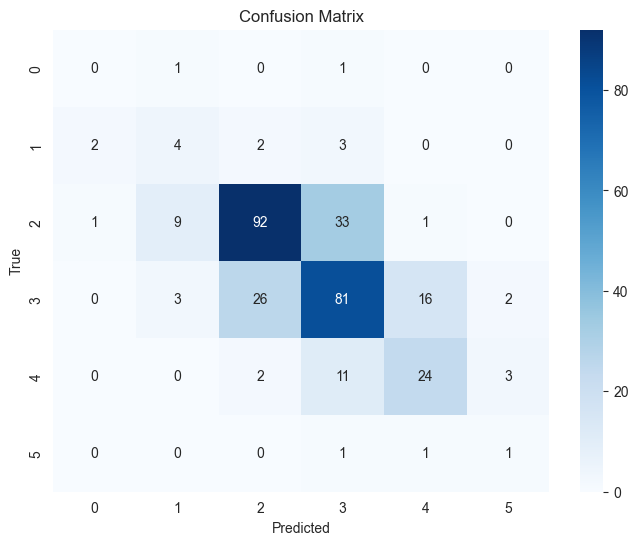


📋 Classification Report (macro avg):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         2
           1     0.2353    0.3636    0.2857        11
           2     0.7541    0.6765    0.7132       136
           3     0.6231    0.6328    0.6279       128
           4     0.5714    0.6000    0.5854        40
           5     0.1667    0.3333    0.2222         3

    accuracy                         0.6312       320
   macro avg     0.3918    0.4344    0.4057       320
weighted avg     0.6508    0.6312    0.6393       320



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
final_model.to(device)

val_loader = dm.val_dataloader()
y_true, y_pred = evaluate_model(final_model, val_loader, device)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(dm.n_classes),
    yticklabels=range(dm.n_classes)
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print('\n📋 Classification Report (macro avg):')
print(classification_report(y_true, y_pred, digits=4))